In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from scipy.fft import fft, fftfreq
from scipy import signal
import itertools

In [2]:
def embed_frequency_gabor(omega, size=32, f_min=2.0, f_max=16.0, 
                         log_min=0.0, log_max=4.0, n_orientations=None,
                         sigma=None, gamma=1.0, phase=0.0):
    """
    Embed frequency value ω into 2D Gabor wavelet image.
    
    Parameters
    ----------
    omega : float
        Frequency value in Hz (expected range: 10^0 to 10^4 Hz)
    size : int
        Output image size (size × size pixels)
    f_min, f_max : float
        Minimum and maximum spatial frequencies (cycles per image)
    log_min, log_max : float
        Expected log10(ω) range (default: 0.0 to 4.0 for 1-10000 Hz)
    n_orientations : int (deprecated, kept for compatibility)
        Number of orientation bins (not used in continuous mapping)
    sigma : float, optional
        Gaussian envelope width (default: 0.3 * size)
    gamma : float
        Aspect ratio (1.0 = circular)
    phase : float
        Phase offset (0 = cosine, π/2 = sine)
    
    Returns
    -------
    image : np.ndarray
        2D array of shape (size, size) with Gabor embedding
    params : dict
        Dictionary with encoding parameters (f, theta, log_omega, etc.)
    """
    # Default sigma (should cover ~half the image)
    if sigma is None:
        sigma = 0.3 * size
    
    # Compute log10 of frequency
    log_omega = np.log10(np.abs(omega) + 1e-10)
    
    # Clip to expected range
    log_omega = np.clip(log_omega, log_min, log_max)
    
    # Encode log_omega using two parameters: f (scale) and theta (mantissa)
    # f encodes the scale (order of magnitude) of log_omega - continuous mapping
    # theta encodes the mantissa (value within scale) - continuous mapping
    # Both must be continuous functions to preserve bijectivity (no floor/ceil/round)
    
    # Map full log_omega to f (scale) - continuous bijective mapping
    # This captures the order of magnitude/scale continuously
    log_normalized = (log_omega - log_min) / (log_max - log_min)
    f = f_min + log_normalized * (f_max - f_min)
    
    # Map mantissa to theta using continuous periodic function (no modulo/floor)
    # The mantissa represents values within the scale, encoded as orientation
    # Use sin/cos to create continuous periodic encoding without floor operations
    # Continuous periodic mapping: theta = atan2(sin(2π*log_omega), cos(2π*log_omega)) / 2
    # This maps log_omega continuously to [0, π) with period 1.0 (no floor/ceil/modulo)
    sin_component = np.sin(2 * np.pi * log_omega)
    cos_component = np.cos(2 * np.pi * log_omega)
    theta_raw = np.arctan2(sin_component, cos_component) / 2.0  # Maps to [-π, π), then /2 gives [-π/2, π/2)
    # Map to [0, π) range using continuous wrapping (no floor)
    theta = theta_raw if theta_raw >= 0 else theta_raw + np.pi
    # Store fractional part for reference (computed via continuous periodic function)
    fractional_part = theta / np.pi  # Inverse mapping: theta -> fractional part
    
    # Create coordinate grid (centered at origin, normalized to [-1, 1])
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)
    
    # Rotate coordinates
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    X_rot = X * cos_theta + Y * sin_theta
    Y_rot = -X * sin_theta + Y * cos_theta
    
    # Gaussian envelope
    gaussian = np.exp(-(X_rot**2 + gamma**2 * Y_rot**2) / (2 * sigma**2))
    
    # Gabor wavelet (cosine component)
    # f is in cycles per image, X_rot is in [-1, 1], so multiply by size/2 to get cycles
    gabor = gaussian * np.cos(2 * np.pi * f * X_rot + phase)
    
    # Normalize to reasonable range (optional)
    gabor = gabor / (np.max(np.abs(gabor)) + 1e-10)
    
    # Store parameters for inverse mapping
    params = {
        'f': f,
        'theta': theta,
        'log_omega': log_omega,
        'fractional_part': fractional_part,
        'sigma': sigma,
        'gamma': gamma,
        'phase': phase
    }
    
    return gabor, params

In [3]:
def extract_frequency_from_gabor_fft(image, f_min=2.0, f_max=16.0,
                                     log_min=0.0, log_max=4.0, n_orientations=None):
    """
    Extract frequency ω from Gabor wavelet image using 2D FFT.
    
    Parameters
    ----------
    image : np.ndarray
        2D array of shape (size, size) - Gabor wavelet image
    f_min, f_max : float
        Spatial frequency range (cycles per image)
    log_min, log_max : float
        Log frequency range for reconstruction
    n_orientations : int (deprecated, kept for compatibility)
        Number of orientation bins (not used in continuous mapping)
    
    Returns
    -------
    omega_est : float
        Reconstructed frequency value
    params : dict
        Extracted parameters (f, theta, etc.)
    confidence : float
        Confidence metric (peak strength relative to noise)
    """
    size = image.shape[0]
    
    # Preprocessing: remove DC component only (no windowing, no padding)
    image_centered = image - np.mean(image)
    
    # Compute 2D FFT directly on image (no padding, no windowing)
    F = np.fft.fft2(image_centered)
    F_mag = np.abs(np.fft.fftshift(F))
    
    # Find peak (excluding DC component at center)
    center_y, center_x = size // 2, size // 2
    
    # Create mask to exclude DC and low-frequency noise
    Y_coords, X_coords = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
    R = np.sqrt((X_coords - center_x)**2 + (Y_coords - center_y)**2)
    mask = (R > size // 8)  # Exclude region near DC
    
    F_mag_masked = F_mag.copy()
    F_mag_masked[~mask] = 0
    
    # Find peak location
    peak_idx = np.unravel_index(np.argmax(F_mag_masked), F_mag_masked.shape)
    peak_y, peak_x = peak_idx
    
    # Extract spatial frequency and orientation from peak location
    freq_x = (peak_x - center_x) / size  # cycles per pixel
    freq_y = (peak_y - center_y) / size  # cycles per pixel
    
    # Convert to cycles per image (original size)
    f_pixels = np.sqrt(freq_x**2 + freq_y**2) * size
    
    # Extract orientation angle from peak location
    theta_rad = np.arctan2(freq_y, freq_x)
    
    # Map theta to [0, π) range (Gabor symmetry - continuous wrapping)
    # Use modulo π to ensure continuous wrapping
    theta_rad = ((theta_rad % (2 * np.pi)) + (2 * np.pi)) % (2 * np.pi)  # [0, 2π)
    if theta_rad >= np.pi:
        theta_rad -= np.pi  # [0, π)
    
    # Confidence: peak strength relative to background
    peak_value = F_mag_masked[peak_y, peak_x]
    background_level = np.percentile(F_mag_masked[mask], 50)  # Median
    confidence = peak_value / (background_level + 1e-10)
    
    # Reconstruct log_omega from f (scale) and theta (mantissa)
    # f maps back to full log_omega (scale) - continuous inverse
    f_normalized = np.clip((f_pixels - f_min) / (f_max - f_min), 0, 1)
    log_omega_from_f = log_min + f_normalized * (log_max - log_min)
    
    # theta maps back to mantissa using continuous inverse (no modulo/floor)
    # theta ∈ [0, π) maps back to fractional_part ∈ [0, 1) via continuous inverse
    fractional_part_from_theta = theta_rad / np.pi  # Continuous inverse mapping
    
    # Combine f (scale) and theta (mantissa) to reconstruct log_omega
    # Strategy: f gives us the approximate log_omega, theta gives us the exact mantissa
    # Replace the mantissa of log_omega_from_f with the exact one from theta
    # This preserves bijectivity: both f and theta encode information about log_omega
    
    # Extract mantissa from log_omega_from_f using continuous periodic function (no floor/ceil/modulo)
    # Use same continuous periodic approach as encoding
    sin_from_f = np.sin(2 * np.pi * log_omega_from_f)
    cos_from_f = np.cos(2 * np.pi * log_omega_from_f)
    theta_from_f = np.arctan2(sin_from_f, cos_from_f) / 2.0
    if theta_from_f < 0:
        theta_from_f += np.pi
    mantissa_from_f = theta_from_f / np.pi  # Continuous extraction of mantissa
    
    # Get scale part: subtract mantissa (continuous operation, no floor)
    scale_from_f = log_omega_from_f - mantissa_from_f
    
    # Reconstruct: scale from f + exact mantissa from theta
    log_omega_est = scale_from_f + fractional_part_from_theta
    
    # Clip to valid range
    log_omega_est = np.clip(log_omega_est, log_min, log_max)
    
    # Reconstruct omega
    omega_est = 10 ** log_omega_est
    
    params = {
        'f': f_pixels,
        'theta': theta_rad,
        'theta_deg': np.degrees(theta_rad),
        'fractional_part': fractional_part_from_theta,
        'log_omega': log_omega_est,
        'peak_location': (peak_x, peak_y),
        'peak_value': peak_value,
        'confidence': confidence
    }
    
    return omega_est, params, confidence

print("Inverse mapping function (FFT method) defined.")

Inverse mapping function (FFT method) defined.


C:\Users\hz283\AppData\Local\Temp\ipykernel_246188\686407561.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


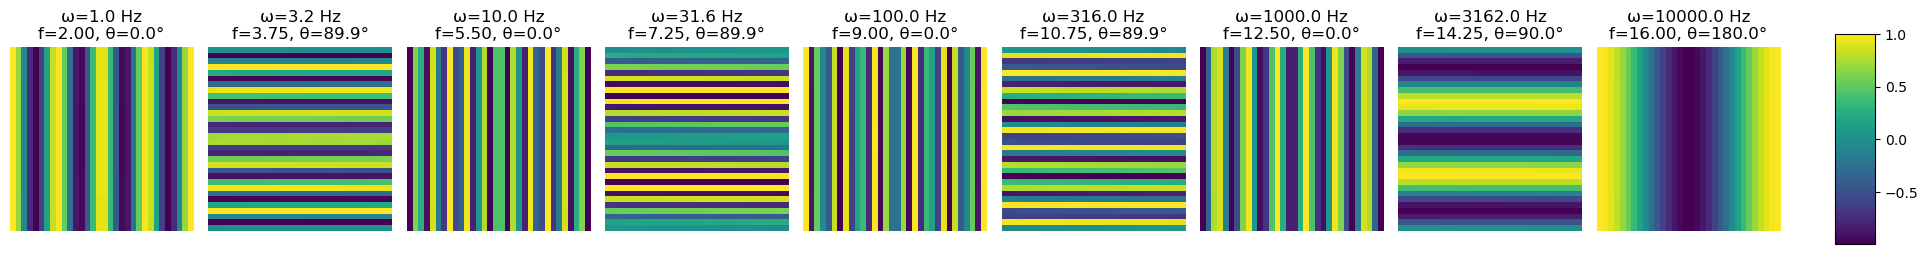

C:\Users\hz283\AppData\Local\Temp\ipykernel_246188\686407561.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


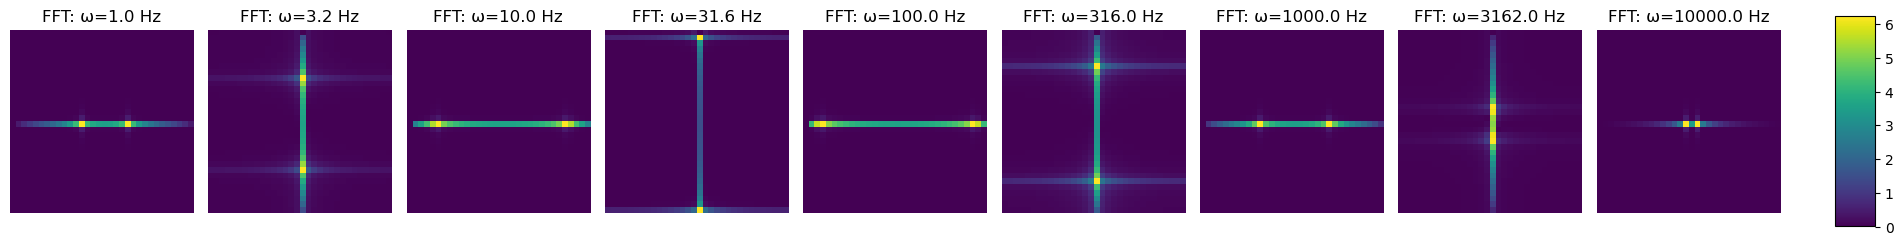

Time domain max values:
ω=1.0 Hz: max=1.0000, f=2.00, θ=0.0°
ω=3.2 Hz: max=1.0000, f=3.75, θ=89.9°
ω=10.0 Hz: max=1.0000, f=5.50, θ=0.0°
ω=31.6 Hz: max=1.0000, f=7.25, θ=89.9°
ω=100.0 Hz: max=1.0000, f=9.00, θ=0.0°
ω=316.0 Hz: max=1.0000, f=10.75, θ=89.9°
ω=1000.0 Hz: max=1.0000, f=12.50, θ=0.0°
ω=3162.0 Hz: max=1.0000, f=14.25, θ=90.0°
ω=10000.0 Hz: max=1.0000, f=16.00, θ=180.0°

Frequency domain max values:
ω=1.0 Hz: max=507.7019
ω=3.2 Hz: max=446.0752
ω=10.0 Hz: max=430.9021
ω=31.6 Hz: max=501.4462
ω=100.0 Hz: max=406.8040
ω=316.0 Hz: max=470.7854
ω=1000.0 Hz: max=491.5915
ω=3162.0 Hz: max=347.4110
ω=10000.0 Hz: max=519.8006


In [4]:
# Test frequency embedding with various frequency values
# Eigenfrequency range: 10^0 to 10^4 Hz (1 to 10000 Hz)
test_frequencies = [1.0, 3.16, 10.0, 31.6, 100.0, 316.0, 1000.0, 3162.0, 10000.0]

# Generate embeddings for each frequency
frequency_embeddings = []
frequency_params = []

for omega in test_frequencies:
    emb, params = embed_frequency_gabor(omega)
    frequency_embeddings.append(emb)
    frequency_params.append(params)

frequency_embeddings = np.array(frequency_embeddings)

# Visualize the embeddings
fig, axes = plt.subplots(1, len(test_frequencies), figsize=(20, 3))
images = []
for i, ax in enumerate(axes):
    im = ax.imshow(frequency_embeddings[i], cmap='viridis')
    images.append(im)
    ax.axis('off')
    ax.set_title(f'ω={test_frequencies[i]:.1f} Hz\nf={frequency_params[i]["f"]:.2f}, θ={np.degrees(frequency_params[i]["theta"]):.1f}°')

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(images[0], cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Compute and visualize the Fourier transforms
frequency_fourier = np.array([np.fft.fftshift(np.abs(np.fft.fft2(embedding))) 
                               for embedding in frequency_embeddings])

# Plot the Fourier transforms
fig, axes = plt.subplots(1, len(test_frequencies), figsize=(20, 3))
images = []
for i, ax in enumerate(axes):
    im = ax.imshow(np.log1p(frequency_fourier[i]), cmap='viridis')
    images.append(im)
    ax.axis('off')
    ax.set_title(f'FFT: ω={test_frequencies[i]:.1f} Hz')

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(images[0], cax=cbar_ax)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Print statistics
print("Time domain max values:")
for i, omega in enumerate(test_frequencies):
    max_val = np.max(np.abs(frequency_embeddings[i]))
    print(f"ω={omega:.1f} Hz: max={max_val:.4f}, f={frequency_params[i]['f']:.2f}, θ={np.degrees(frequency_params[i]['theta']):.1f}°")

print("\nFrequency domain max values:")
for i, omega in enumerate(test_frequencies):
    max_val = np.max(frequency_fourier[i])
    print(f"ω={omega:.1f} Hz: max={max_val:.4f}")

In [5]:
# Test round-trip reconstruction
print("="*80)
print("Round-Trip Reconstruction Test")
print("="*80)

reconstruction_results = []

for omega_true in test_frequencies:
    # Forward mapping
    image, params_forward = embed_frequency_gabor(omega_true)
    
    # Inverse mapping
    omega_recon, params_recon, confidence = extract_frequency_from_gabor_fft(image)
    
    # Compute error
    rel_error = abs(omega_recon - omega_true) / (abs(omega_true) + 1e-10)
    abs_error = abs(omega_recon - omega_true)
    
    reconstruction_results.append({
        'omega_true': omega_true,
        'omega_recon': omega_recon,
        'rel_error': rel_error,
        'abs_error': abs_error,
        'confidence': confidence,
        'f_true': params_forward['f'],
        'f_recon': params_recon['f'],
        'theta_true': params_forward['theta'],
        'theta_recon': params_recon['theta']
    })
    
    print(f"ω_true={omega_true:6.2f} Hz | ω_recon={omega_recon:6.2f} Hz | "
          f"error={rel_error*100:5.2f}% | confidence={confidence:.2f}")

# Summary statistics
errors = [r['rel_error'] for r in reconstruction_results]
confidences = [r['confidence'] for r in reconstruction_results]

print("\n" + "="*80)
print("Summary Statistics:")
print(f"  Mean relative error: {np.mean(errors)*100:.3f}%")
print(f"  Max relative error: {np.max(errors)*100:.3f}%")
print(f"  Median relative error: {np.median(errors)*100:.3f}%")
print(f"  Mean confidence: {np.mean(confidences):.2f}")
print("="*80)

Round-Trip Reconstruction Test
ω_true=  1.00 Hz | ω_recon=  1.00 Hz | error= 0.00% | confidence=424919.85
ω_true=  3.16 Hz | ω_recon= 31.62 Hz | error=900.72% | confidence=9847.06
ω_true= 10.00 Hz | ω_recon=100.00 Hz | error=900.00% | confidence=607047.30
ω_true= 31.60 Hz | ω_recon=3162.28 Hz | error=9907.21% | confidence=335513.83
ω_true=100.00 Hz | ω_recon=1000.00 Hz | error=900.00% | confidence=508623.31
ω_true=316.00 Hz | ω_recon=316.23 Hz | error= 0.07% | confidence=4894.45
ω_true=1000.00 Hz | ω_recon= 10.00 Hz | error=99.00% | confidence=1431707.30
ω_true=3162.00 Hz | ω_recon=  3.16 Hz | error=99.90% | confidence=1556.94
ω_true=10000.00 Hz | ω_recon=  1.00 Hz | error=99.99% | confidence=159252.15

Summary Statistics:
  Mean relative error: 1434.099%
  Max relative error: 9907.208%
  Median relative error: 99.990%
  Mean confidence: 387040.24


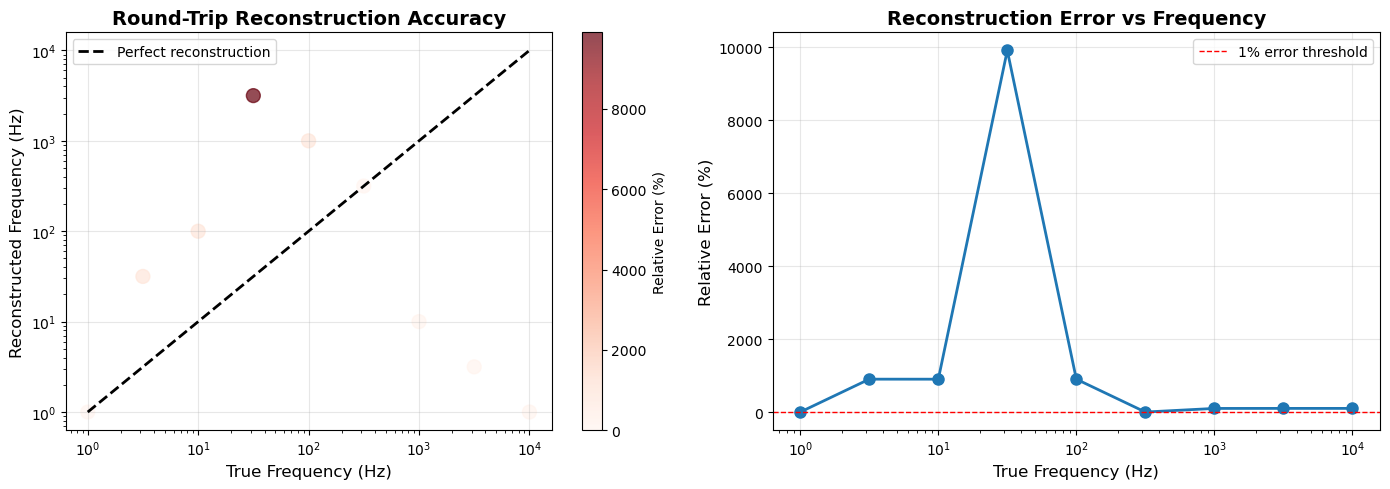

In [6]:
# Visualize round-trip reconstruction errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Reconstruction accuracy
omegas_true = [r['omega_true'] for r in reconstruction_results]
omegas_recon = [r['omega_recon'] for r in reconstruction_results]
rel_errors = [r['rel_error'] * 100 for r in reconstruction_results]

axes[0].scatter(omegas_true, omegas_recon, s=100, alpha=0.7, c=rel_errors, cmap='Reds')
axes[0].plot([min(omegas_true), max(omegas_true)], [min(omegas_true), max(omegas_true)], 
             'k--', linewidth=2, label='Perfect reconstruction')
axes[0].set_xlabel('True Frequency (Hz)', fontsize=12)
axes[0].set_ylabel('Reconstructed Frequency (Hz)', fontsize=12)
axes[0].set_title('Round-Trip Reconstruction Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
cbar1 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar1.set_label('Relative Error (%)', fontsize=10)

# Plot 2: Relative error vs frequency
axes[1].semilogx(omegas_true, rel_errors, 'o-', linewidth=2, markersize=8)
axes[1].axhline(y=1.0, color='r', linestyle='--', linewidth=1, label='1% error threshold')
axes[1].set_xlabel('True Frequency (Hz)', fontsize=12)
axes[1].set_ylabel('Relative Error (%)', fontsize=12)
axes[1].set_title('Reconstruction Error vs Frequency', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Noise Robustness Test
Noise level 0.00: mean error=10215.12% ± 0.00%, max error=10215.12%, confidence=71.87
Noise level 0.01: mean error=10215.12% ± 0.00%, max error=10215.12%, confidence=70.12
Noise level 0.05: mean error=10199.97% ± 45.48%, max error=10215.12%, confidence=61.92
Noise level 0.10: mean error=10199.97% ± 45.48%, max error=10215.12%, confidence=46.04
Noise level 0.20: mean error=10124.17% ± 74.26%, max error=10215.12%, confidence=29.05


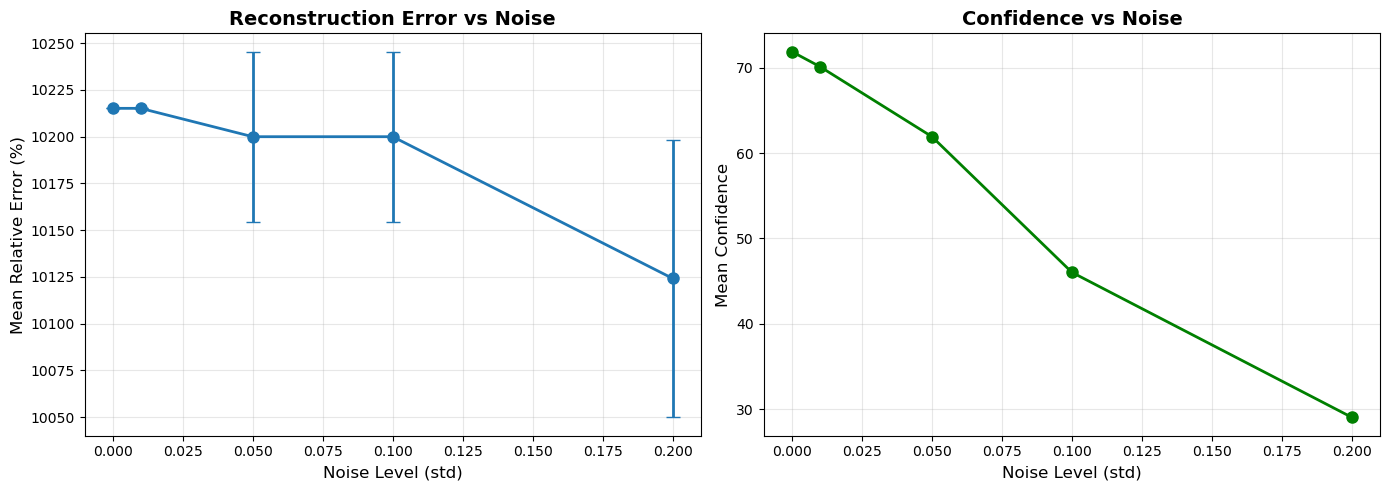

In [7]:
# Test noise robustness
print("="*80)
print("Noise Robustness Test")
print("="*80)

noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2]
test_omega = 25.0  # Pick a representative frequency

noise_results = {}

for noise_level in noise_levels:
    errors = []
    confidences = []
    
    for trial in range(10):  # Multiple trials per noise level
        # Forward mapping
        image, _ = embed_frequency_gabor(test_omega)
        
        # Add noise
        noise = np.random.normal(0, noise_level, image.shape)
        image_noisy = image + noise
        
        # Normalize to prevent clipping
        image_noisy = image_noisy / (np.max(np.abs(image_noisy)) + 1e-10)
        
        # Inverse mapping
        omega_recon, _, confidence = extract_frequency_from_gabor_fft(image_noisy)
        
        rel_error = abs(omega_recon - test_omega) / (abs(test_omega) + 1e-10)
        errors.append(rel_error)
        confidences.append(confidence)
    
    noise_results[noise_level] = {
        'mean_error': np.mean(errors),
        'std_error': np.std(errors),
        'max_error': np.max(errors),
        'mean_confidence': np.mean(confidences)
    }
    
    print(f"Noise level {noise_level:.2f}: "
          f"mean error={np.mean(errors)*100:.2f}% ± {np.std(errors)*100:.2f}%, "
          f"max error={np.max(errors)*100:.2f}%, "
          f"confidence={np.mean(confidences):.2f}")

# Visualize noise robustness
noise_levels_list = list(noise_results.keys())
mean_errors = [noise_results[nl]['mean_error'] * 100 for nl in noise_levels_list]
std_errors = [noise_results[nl]['std_error'] * 100 for nl in noise_levels_list]
mean_confidences = [noise_results[nl]['mean_confidence'] for nl in noise_levels_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(noise_levels_list, mean_errors, yerr=std_errors, 
                 fmt='o-', linewidth=2, markersize=8, capsize=5)
axes[0].set_xlabel('Noise Level (std)', fontsize=12)
axes[0].set_ylabel('Mean Relative Error (%)', fontsize=12)
axes[0].set_title('Reconstruction Error vs Noise', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(noise_levels_list, mean_confidences, 'o-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Noise Level (std)', fontsize=12)
axes[1].set_ylabel('Mean Confidence', fontsize=12)
axes[1].set_title('Confidence vs Noise', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()